In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


 
- Arrowhead Beach: 36.236102, -76.695387 (Planet 4)

- Cannon's Ferry: 36.271557, -76.672967 (Planet 6)

- Rocky Hock: 36.183649, -76.719210 (Planet 3)

- Chowan River Bridge: 36.055233, -76.686425 (Planet 5)

- Point Comfort: 36.169458, -76.751827 (Planet 1)

- Mt. Gould : 36.123866, -76.742630 (Planet 2)

In [2]:
class Weak_Supervision_Dataset():    
    def __init__(self, img_dir,lbl_dir, lat, lon, transforms=None):
        
        self.transforms = transforms
        markers = set()
        self.planet_paths = []
        self.sentinel_paths = {}
        self.cicyano_paths ={}
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.lat = lat,
        self.lon = lon

        for file in sorted(listdir(self.img_dir)):
            parts = file.split('_')[0]  
            if parts not in markers:
                self.planet_paths.append(os.path.join(self.img_dir, file))
                markers.add(parts)

        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'CIcyano':
                            if marker not in self.cicyano_paths: 
                                self.cicyano_paths[marker] = os.path.join(folder_path, file)
                                
        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'truecolor':
                            if marker not in self.sentinel_paths: 
                                self.sentinel_paths[marker] = os.path.join(folder_path, file)
                                

        self.matches = {}
        for img_path in self.planet_paths:
            img_marker = img_path.split('/')[-1].split('_')[0]  
            if img_marker in markers:
                self.matches[img_marker] = {
                    'planet': img_path,
                    'cicyano': self.cicyano_paths.get(img_marker, None),
                    'sentinel': self.sentinel_paths.get(img_marker,None)
                }
        
        self.matches = {marker: paths for marker, paths in self.matches.items() if paths['cicyano'] is not None}
        self.keys = list(self.matches.keys())

    def __len__(self): return len(self.matches)
    
    def __getitem__(self, idx):
        marker = self.keys[idx]
        
        #planet image handling 
        with rio.open(self.matches[marker]['planet']) as rds:
            data = rds.read([1,2,3])
            planet_data = np.array(data) #shape (3,600,600)
            planet_data = np.moveaxis(planet_data, 0,2) #to match axis order of NASA data
            
        with rio.open(self.matches[marker]['sentinel']) as rds:
            data = rds.read([1,2,3])
            unalt = data
            crop_size = 2.5

            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)
     
            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            data = np.moveaxis(data, 0, 2)  
            sentinel_data = np.array(data)

        #label handling
        with rio.open(self.matches[marker]['cicyano']) as rds:
            data = rds.read()
            crop_size = 2.5
            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            data = np.moveaxis(data, 0, 2)  
            lbl_arr = np.array(data)

            fpt_avg = np.where((31 <= lbl_arr) & (lbl_arr<= 249), lbl_arr, 0) #bloom pixel avg only
            fpt_avg = fpt_avg[fpt_avg !=0]
            mean_value = fpt_avg.mean() if fpt_avg.size > 0 else 0

            #label with land (2), cloud (3), bloom (1), else (0)
            fptdata = np.where(lbl_arr == 252, 2, np.where(lbl_arr == 253, 3, np.where((31 <= lbl_arr) & (lbl_arr<= 249), 1, 0)))

            if 31 <= mean_value <= 249:
                class_lbl = 1
            else: class_lbl = 0
                

        sample ={'planet': planet_data,
                  'planet_file': self.matches[marker]['planet'],
                  'sentinel': sentinel_data,
                  'sentinel_file': self.matches[marker]['sentinel'],
                  'cicyano': fptdata,
                  'cicyano_file': self.matches[marker]['cicyano'],
                  'ci_avg': round(mean_value),
                  'class_label': class_lbl
                 }

        if self.transforms:
            sample = self.transforms(sample)

        return sample
        
    def display(self, idx):

        sample = self[idx]
        planet = sample['planet']
        sentinel = sample['sentinel']
        cicyano = sample['cicyano']
        label = sample['ci_avg']

        class_label = sample['class_label']
        inf = sample['planet_file'].split('/')

        d=inf[-1].split('_')[0]
        d = d[4:6]+'-'+d[6:]+'-'+d[:4]
        p = inf[-2]
        
        colors = ['black', 'seagreen', 'yellow', 'grey']  # Set your desired colors for each class here
        cmap = ListedColormap(colors)
        boundaries = [0, 1, 2, 3, 4]  # Each boundary represents a class (0, 1, 2, 3)
        norm = BoundaryNorm(boundaries, cmap.N)
        fig,(ax1, ax2,ax3) = plt.subplots(1,3, figsize=(15,15))
        fig.suptitle(f' {d} at {p}',y=0.68)
        
        ax1.imshow(planet, zorder=1)
        ax1.axis('off')
        ax1.set_title(f'Planet')
#         grid_color = 'white'
#         linewidth = 0.1
#         for i in range(1, 5):
#             # Draw vertical lines
#             ax1.vlines(x=planet.shape[1] * i / 5, ymin=0, ymax=planet.shape[0], color=grid_color, linewidth=linewidth)
#             # Draw horizontal lines
#             ax1.hlines(y=planet.shape[0] * i / 5, xmin=0, xmax=planet.shape[1], color=grid_color, linewidth=linewidth)

 
        ax2.imshow(cicyano, cmap=cmap,norm=norm)
        ax2.axis('off')
        ax2.set_title(f'Class Label: {class_label}')

        ax3.imshow(sentinel)
        ax3.axis('off')
        ax3.set_title(f'Sentinel Avg Label: {round(label)}')
        plt.show()

        return fig


def create_dataset(*args, apply_transforms=True, **kwargs):
    if apply_transforms:
        data_transforms = transforms.Compose([
            FlipsAndTricks(),
            CropAndChop(224),
#             Normalize(),
            ToTensor(),])
    else: data_transforms = None

    data = Weak_Supervision_Dataset(*args, **kwargs, transforms=data_transforms)
    return data

In [3]:
lbl_dir = '/datacommons/carlsonlab/srs108/blooms/all_data'

img_dir = '/datacommons/carlsonlab/srs108/crops/arrowhead_beach/'
lat,lon = 36.236724, -76.698134
a=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/cannons_ferry/'
lat,lon = 36.272006, -76.675842
b=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/chowan_river/'
lat,lon = 36.055163, -76.690760
c=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/mt_gould/'
lat,lon = 36.125495, -76.740141
d=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/point_comfort/'
lat,lon = 36.169908, -76.745905
e=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/rocky_hock_lane/'
lat,lon = 36.184133, -76.722858
f=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)
all_chowan = torch.utils.data.ConcatDataset([a,b,c,d,e,f])

val_ratio, test_ratio = 0.25, 0.25
dataset_size = len(all_chowan)
indices = list(range(dataset_size))
batch_size = 8

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(all_chowan, train_indices)
val_dataset = Subset(all_chowan, val_indices)
test_dataset = Subset(all_chowan, test_indices)

In [4]:
# all_labels = [train_dataset[i]['class_label'] for i in tqdm(range(len(train_dataset)),position=0, leave=True)]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [5]:
# torch.save((class_counts, class_weights, sample_weights), 'binary_weights.pth')
class_counts, class_weights, sample_weights = torch.load('binary_weights.pth')

In [6]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last = True)

In [24]:
# def double_conv(in_c, out_c):
#     conv = nn.Sequential(
#         nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#         nn.ReLU(True),
#         nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
#         nn.ReLU(True)
#     )
#     return conv

# class UNET(nn.Module):
#     def __init__(self):
#         super(UNET, self).__init__()
        
#         self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.downconv1 = double_conv(3,64)
#         self.downconv2 = double_conv(64, 128)
#         self.downconv3 = double_conv(128,256)
#         self.downconv4 = double_conv(256, 512)
#         self.downconv5 = double_conv(512,1024)
        
#         #UNET Decoding
#         self.uptrans1 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)
#         self.upconv1 = double_conv(1024, 512)
        
#         self.uptrans2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
#         self.upconv2 = double_conv(512, 256)
        
#         self.uptrans3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
#         self.upconv3 = double_conv(256, 128)
        
#         self.uptrans4 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
#         self.upconv4 = double_conv(128, 64)
        
#         self.out = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=1)
        
        
#         self.class_out = nn.AdaptiveAvgPool2d((1, 1))
#         self.class_out2 = nn.Linear(32, 1)
        
#     def encoder(self, img):
#         self.x1 = self.downconv1(img)
#         self.x2 = self.maxpool(self.x1)
#         self.x3 = self.downconv2(self.x2)
#         self.x4 = self.maxpool(self.x3)
#         self.x5 = self.downconv3(self.x4)
#         self.x6 = self.maxpool(self.x5)
#         self.x7 = self.downconv4(self.x6)
#         self.x8 = self.maxpool(self.x7)
#         self.x9 = self.downconv5(self.x8)
#         return self.x9

#     def forward(self, segimg):
        
#         segout = self.encoder(segimg)

#         x = self.uptrans1(segout)
#         x =self.upconv1(torch.cat([self.x7,x], 1))

#         x = self.uptrans2(x)
#         x = self.upconv2(torch.cat([self.x5,x],1))

#         x = self.uptrans3(x)
#         x = self.upconv3(torch.cat([self.x3,x], 1))

#         x = self.uptrans4(x)
#         x = self.upconv4(torch.cat([self.x1,x],1))


#         x = self.out(x)
# #         print(x.shape)
#         x = self.class_out(x)
# #         print(x.shape)
#         x = x.view(x.size(0), -1)
#         x = self.class_out2(x)
#         return x
    
# semimg = torch.rand((1,3,512,512))
# model = UNET()
# x = model(semimg)


In [ ]:
import torch
import torch.nn.functional as F

class MTL_SCRATCH_NET_CAM(MTL_SCRATCH_NET):
    def __init__(self):
        super(MTL_SCRATCH_NET_CAM, self).__init__()

    def get_cam(self, segimg):
        """
        Compute the Class Activation Map (CAM) and return a binary segmentation map.

        Args:
            segimg (torch.Tensor): Input image tensor of shape (batch_size, 3, H, W).

        Returns:
            torch.Tensor: Binary segmentation map of shape (batch_size, H, W).
        """
        # Forward pass to get the last layer's output
        segout = self.encoder(segimg)

        x = self.uptrans1(segout)
        x = self.upconv1(torch.cat([self.x7, x], 1))
        x = self.uptrans2(x)
        x = self.upconv2(torch.cat([self.x5, x], 1))
        x = self.uptrans3(x)
        x = self.upconv3(torch.cat([self.x3, x], 1))
        x = self.uptrans4(x)
        x = self.upconv4(torch.cat([self.x1, x], 1))
        
        # Get the output of the last convolutional layer
        last_conv_output = self.out(x)  # Shape: (batch_size, 32, H, W)

        # Global Average Pooling (GAP)
        gap_output = self.class_out(last_conv_output)  # Shape: (batch_size, 32, 1, 1)
        gap_output = gap_output.view(gap_output.size(0), -1)  # Shape: (batch_size, 32)

        # Get the weights of the fully connected layer
        fc_weights = self.class_out2.weight  # Shape: (1, 32)

        # Compute the CAM
        cam = torch.einsum("bchw,oc->bohw", last_conv_output, fc_weights)  # Weighted sum
        cam = cam.squeeze(1)  # Remove the channel dimension; Shape: (batch_size, H, W)

        # Normalize the CAM (optional, for better visualization)
        cam_min, cam_max = cam.min(dim=[1, 2], keepdim=True)[0], cam.max(dim=[1, 2], keepdim=True)[0]
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)  # Normalize to [0, 1]

        # Threshold the CAM to obtain binary segmentation map
        binary_segmentation = (cam > 0.5).float()  # Shape: (batch_size, H, W)

        return cam, binary_segmentation


In [25]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0

    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['planet'].float().to(device)
            y = batch['class_label'].float().to(device)
            output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1)
                    
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1
#             print(output_binary)
            loss = criterion(output,y)
            running_loss += loss.item()
            
            #accuracy
            label = y.cpu().detach().numpy()
            acc = accuracy_score(label,output_binary)
            running_acc += acc

            torch.cuda.empty_cache()
        return running_loss/len(dataloader), running_acc/len(dataloader)
            

In [29]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    model.train()

    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['planet'].float().to(device)
        y = batch['class_label'].float().to(device) 

        output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1) #outputs logits (outputs before activation)
        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom
        #loss
#         print(output_binary)
        loss = criterion(output,y) #BCEwL
        running_loss += loss.item()

        #accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label,output_binary)
        running_acc += acc

        opt.zero_grad()
        loss.backward()
        opt.step()
        torch.cuda.empty_cache()

    return running_loss/len(dataloader), running_acc/len(dataloader)

In [30]:
def main(model, epochs):
    opt                        = optim.Adam(model.parameters(), lr=1e-5)#, momentum=0.9)
    criterion                  = nn.BCEWithLogitsLoss().to(device)  
    best_loss                 = 1e6
    patience                   = np.ceil(0.1*epochs)
    trigger_times              = 0
    history = {'epoch':[],'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc':[]}

    for epoch in range(1, epochs+1):

        train_loss, train_acc = train(model,  train_loader, criterion, opt, epoch, device)
        val_loss, val_acc = test(model, val_loader, criterion, device)


        if val_loss < best_loss:
            trigger_times = 0
            best_loss = val_loss
            best_model_weights = model.state_dict()
            torch.save(model.state_dict(), 'u.pt')

        else:
            trigger_times += 1
            if trigger_times == patience:
                print(f"Early stopping on epoch {epoch} - patience reached")
                break

        print(f'Epoch {epoch}\n\tCurrent train/val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}\n\tCurrent train/val Accuracy: {round(train_acc,5)}/{round(val_acc,5)}')

        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        df = pd.DataFrame(history)
        df.to_csv('u.csv', index=False)

In [ ]:
# model = UNET().to(device)
model  = smp.Unet(encoder_name = 'resnet18', encoder_weights = 'imagenet', in_channels = 3,classes = 4).to(device)

# model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/binary/binary.pt'))
main(epochs=200, model=model)
# %time

301it [05:02,  1.01s/it]
151it [02:24,  1.04it/s]
0it [00:00, ?it/s]

Epoch 1
	Current train/val Loss: 0.69127/0.61377
	Current train/val Accuracy: 0.52436/0.82699


301it [05:05,  1.01s/it]
151it [02:17,  1.10it/s]
0it [00:00, ?it/s]

Epoch 2
	Current train/val Loss: 0.69097/0.64943
	Current train/val Accuracy: 0.53834/0.73096
	Current Triggers: 1


301it [05:00,  1.00it/s]
151it [02:23,  1.05it/s]
0it [00:00, ?it/s]

...

301it [05:25,  1.08s/it]
151it [02:31,  1.01s/it]
0it [00:00, ?it/s]

Epoch 6
	Current train/val Loss: 0.68734/0.66484
	Current train/val Accuracy: 0.54873/0.56457
	Current Triggers: 2


301it [05:18,  1.06s/it]
151it [02:35,  1.03s/it]
0it [00:00, ?it/s]

Epoch 7
	Current train/val Loss: 0.69181/0.71197
	Current train/val Accuracy: 0.53571/0.41474
	Current Triggers: 3


57it [01:03,  1.01it/s]

# Post Run
## Plots

In [10]:
df = pd.read_csv('/datacommons/carlsonlab/srs108/weak/unet/u.csv')

In [11]:
trl = min(df['train_loss'])
vl = min(df['val_loss'])
tra = max(df['train_acc'])
va = max(df['val_acc'])

In [12]:
print(f'Training Accuracy: {tra}\nValidation Accuracy: {va}\nTraining Loss: {trl}\nValidation Loss: {vl}')

Training Accuracy: 0.6099114064230343
Validation Accuracy: 0.7715231788079471
Training Loss: 0.6468542746927255
Validation Loss: 0.6028169571169165


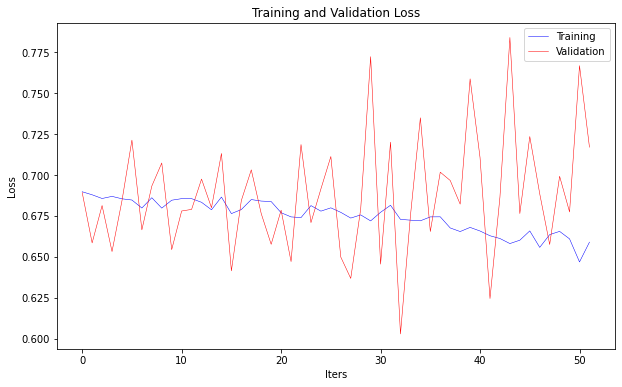

In [13]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=False)

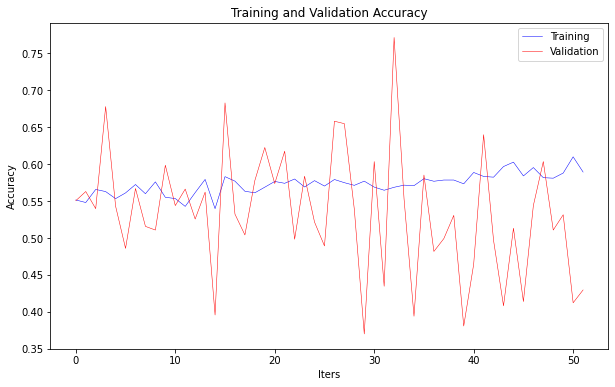

In [14]:
train_val_acc(df['train_acc'], df['val_acc'], len(df['epoch']), save=False)

## Testing

In [17]:
model = UNET().to(device)

model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/unet/u.pt'))

<All keys matched successfully>

In [18]:
criterion = nn.BCEWithLogitsLoss().to(device)  

model.eval()
running_loss = 0
running_acc = 0

all_labels_for_auc = []
all_outputs_for_auc = []

all_binary_for_cm = []
all_labels_for_cm = []
all_outputs_for_cm = []

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['planet'].float().to(device)
        y = batch['class_label'].float().to(device) 
        c = batch['ci_avg'].to(device)
        output = model(torch.permute(x, (0,3,1,2))).squeeze(dim=1)

        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1

        loss = criterion(output, y)
        running_loss += loss.item()

        all_labels_for_auc.append(y.cpu().detach().numpy())
        all_outputs_for_auc.append(output.cpu().detach().numpy())
        
        all_labels_for_cm.extend(y.cpu().detach().numpy().tolist())  # Append only values
        all_outputs_for_cm.extend(output.cpu().detach().numpy().tolist())  # Append only values
        all_binary_for_cm.extend(output_binary.tolist()) 

        # accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label, output_binary)
        running_acc += acc
       
#         bloom_image_plotting(batch, output_binary,y,c)
        torch.cuda.empty_cache()
# AUC
all_labels_for_auc = np.concatenate(all_labels_for_auc)
all_outputs_for_auc = np.concatenate(all_outputs_for_auc)
auc = roc_auc_score(all_labels_for_auc, all_outputs_for_auc)
fpr, tpr, thresholds = roc_curve(all_labels_for_auc, all_outputs_for_auc)

150it [09:02,  3.61s/it]


In [ ]:
print(auc)

print('Testing Accuracy',running_acc/len(test_loader))
print('Testing Loss',running_loss/len(test_loader))

plot_roc_curve(fpr, tpr, auc, save=False)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)
sns.heatmap(cm,annot=True,cmap='Blues', fmt='g',xticklabels=['no bloom', 'bloom'], 
            yticklabels=['no bloom', 'bloom'])


In [ ]:

#     fig,ax= plt.subplots(6,2,figsize = (12,12))
#     colors = ['black', 'seagreen', 'yellow', 'grey']  # Set your desired colors for each class here
#     cmap = ListedColormap(colors)
#     boundaries = [0, 1, 2, 3, 4]  # Each boundary represents a class (0, 1, 2, 3)

#     norm = BoundaryNorm(boundaries, cmap.N)        
#     ax[0,0].imshow(batch['planet'][0])
#     ax[0,0].set_title(f'output: {output_binary[0].item()}')
#     ax[0,0].axis('off')

#     ax[0,1].imshow(batch['cicyano'][0],  cmap=cmap,norm=norm)
#     ax[0,1].set_title(f'label: {y[0]}, fpt: {c[0]}')
#     ax[0,1].axis('off')

#     ax[1,0].imshow(batch['planet'][1])
#     ax[1,0].set_title(f'output: {output_binary[1].item()}')
#     ax[1,0].axis('off')

#     ax[1,1].imshow(batch['cicyano'][1], cmap=cmap,norm=norm)
#     ax[1,1].set_title(f'label: {y[1]}, fpt: {c[1]}')
#     ax[1,1].axis('off')

#     ax[2,0].imshow(batch['planet'][2])
#     ax[2,0].set_title(f'output: {output_binary[2].item()}')
#     ax[2,0].axis('off')

#     ax[2,1].imshow(batch['cicyano'][2], cmap=cmap,norm=norm)
#     ax[2,1].set_title(f'label: {y[2]}, fpt: {c[2]}')
#     ax[2,1].axis('off')

#     ax[3,0].imshow(batch['planet'][3])
#     ax[3,0].set_title(f'output: {output_binary[3].item()}')
#     ax[3,0].axis('off')

#     ax[3,1].imshow(batch['cicyano'][3], cmap=cmap,norm=norm)
#     ax[3,1].set_title(f'label: {y[3]}, fpt: {c[3]}')
#     ax[3,1].axis('off')

#     ax[4,0].imshow(batch['planet'][4])
#     ax[4,0].set_title(f'output: {output_binary[4].item()}')
#     ax[4,0].axis('off')

#     ax[4,1].imshow(batch['cicyano'][4], cmap=cmap,norm=norm)
#     ax[4,1].set_title(f'label: {y[4]}, fpt: {c[4]}')
#     ax[4,1].axis('off')
    
#     ax[5,0].imshow(batch['planet'][5])
#     ax[5,0].set_title(f'output: {output_binary[5].item()}')
#     ax[5,0].axis('off')

#     ax[5,1].imshow(batch['cicyano'][5], cmap=cmap,norm=norm)
#     ax[5,1].set_title(f'label: {y[5]}, fpt: {c[5]}')
#     ax[5,1].axis('off')    
#     fig.tight_layout()
#     plt.show()
#     plt.close()